In [3]:
import h5py
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import os

plt.style.use('../libs/my_style.mplstyle')

#root = Path('/mnt/e/Sasaki/MTsingleBeads')
root = Path('/Volumes/My Passport/Sasaki/MTsingleBeads')

path0 = root / "20260121" / 'exp_crop1'
path1 = root / "20260121" / 'beads_trans_crop_crop'
path2 = root / "20260122" / "exp"
path3 = root / "20260122" / 'exp001'

path_list = [path0, path1, path2, path3]

def load_metrics(path_list, file_name='GFP_flows_metrics.h5'):
    all_se = []
    all_ae = []

    for path in path_list:
        with h5py.File(path / file_name, 'r') as f:
            speed_err = f['speed_error'][:]
            angle_err = f['orientation_error_deg'][:]
            all_se.extend(speed_err)
            all_ae.extend(angle_err)

    return np.array(all_se), np.array(all_ae)

save_path = Path("/Users/sasakinozomu/code/MTCargo_analysis/notebooks/figures/DLOF_err")

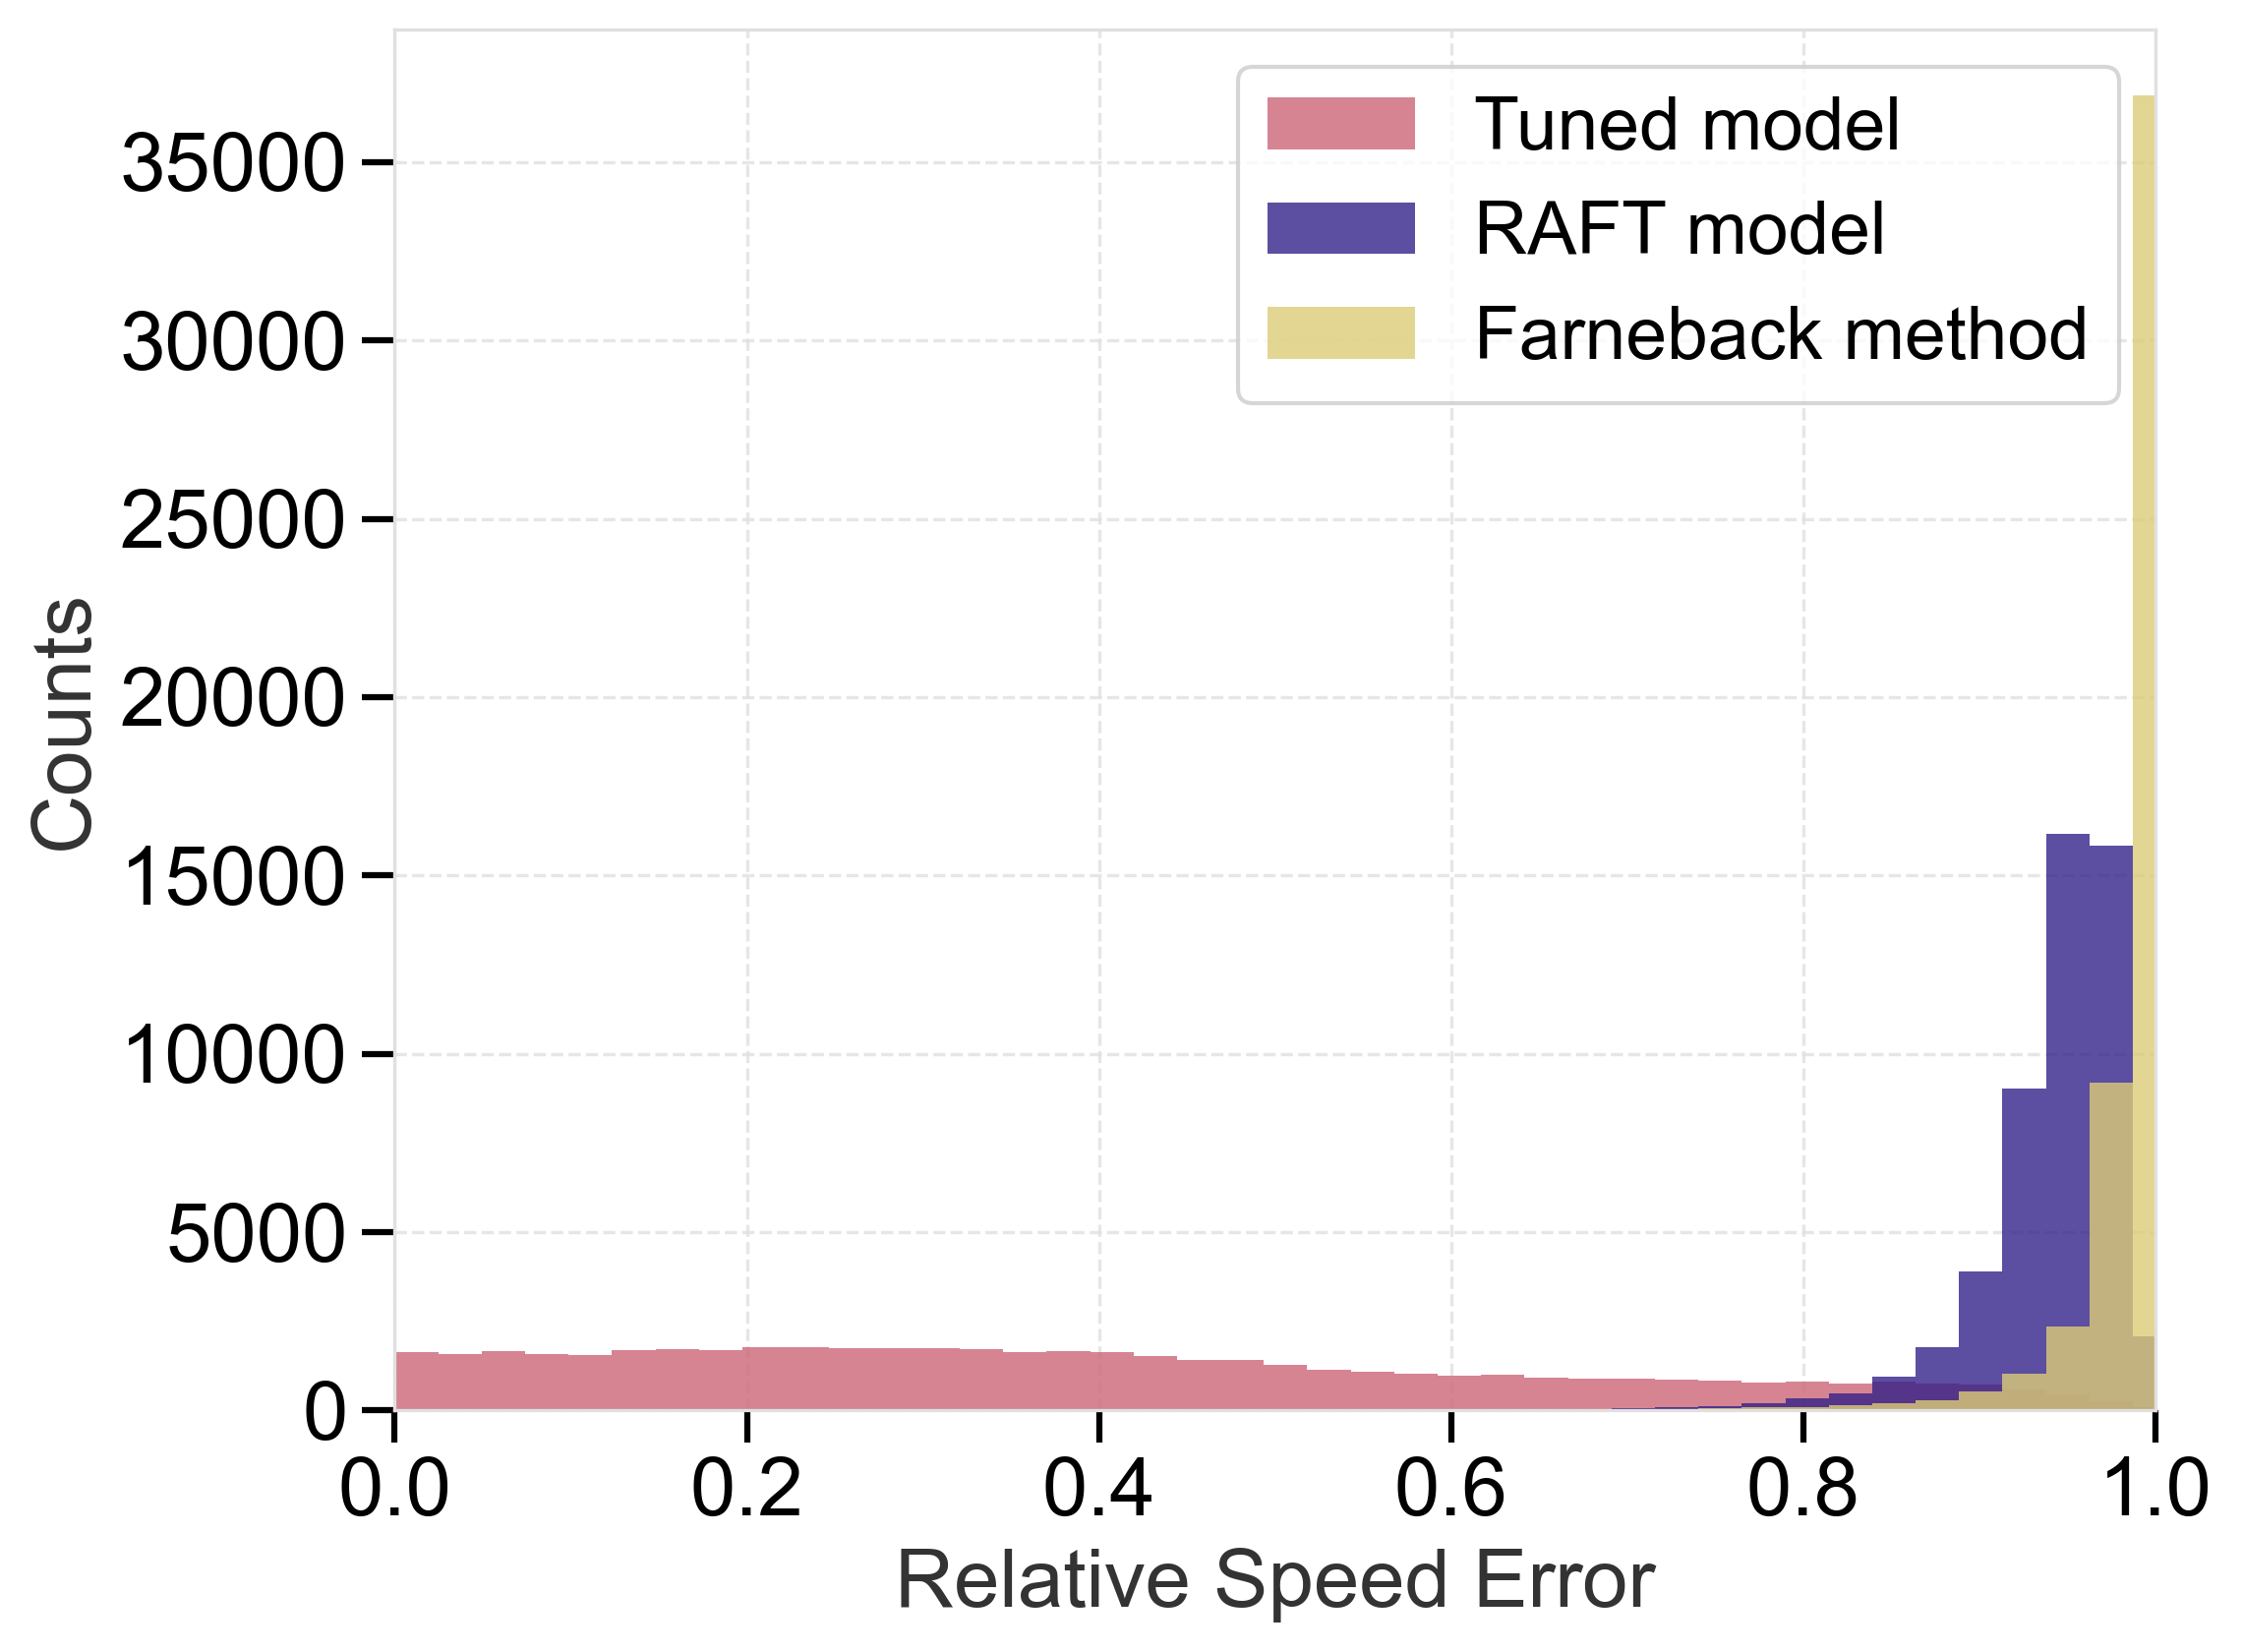

In [4]:
good_se, good_ae = load_metrics(path_list, file_name='good_eval.h5')
bad_se, bad_ae = load_metrics(path_list, file_name='bad_eval.h5')
fb_se, fb_ae = load_metrics(path_list, file_name='Farneback_metrics.h5')

fig, ax = plt.subplots()
edge = np.histogram_bin_edges(good_se, bins="sqrt")
ax.hist(good_se, bins=edge, density=False, alpha = 0.8, label = 'Tuned model')
ax.hist(bad_se, bins=edge, density=False, alpha = 0.8, label = 'RAFT model')
ax.hist(fb_se, bins=edge, density=False, alpha = 0.8, label = 'Farneback method')
ax.set_xlim(0, 1)
ax.set_xlabel("Relative Speed Error")
ax.set_ylabel("Counts")
ax.legend()
plt.show()

fig.savefig(save_path / 'RSE.png')
fig.savefig(save_path / 'RSE.pdf')

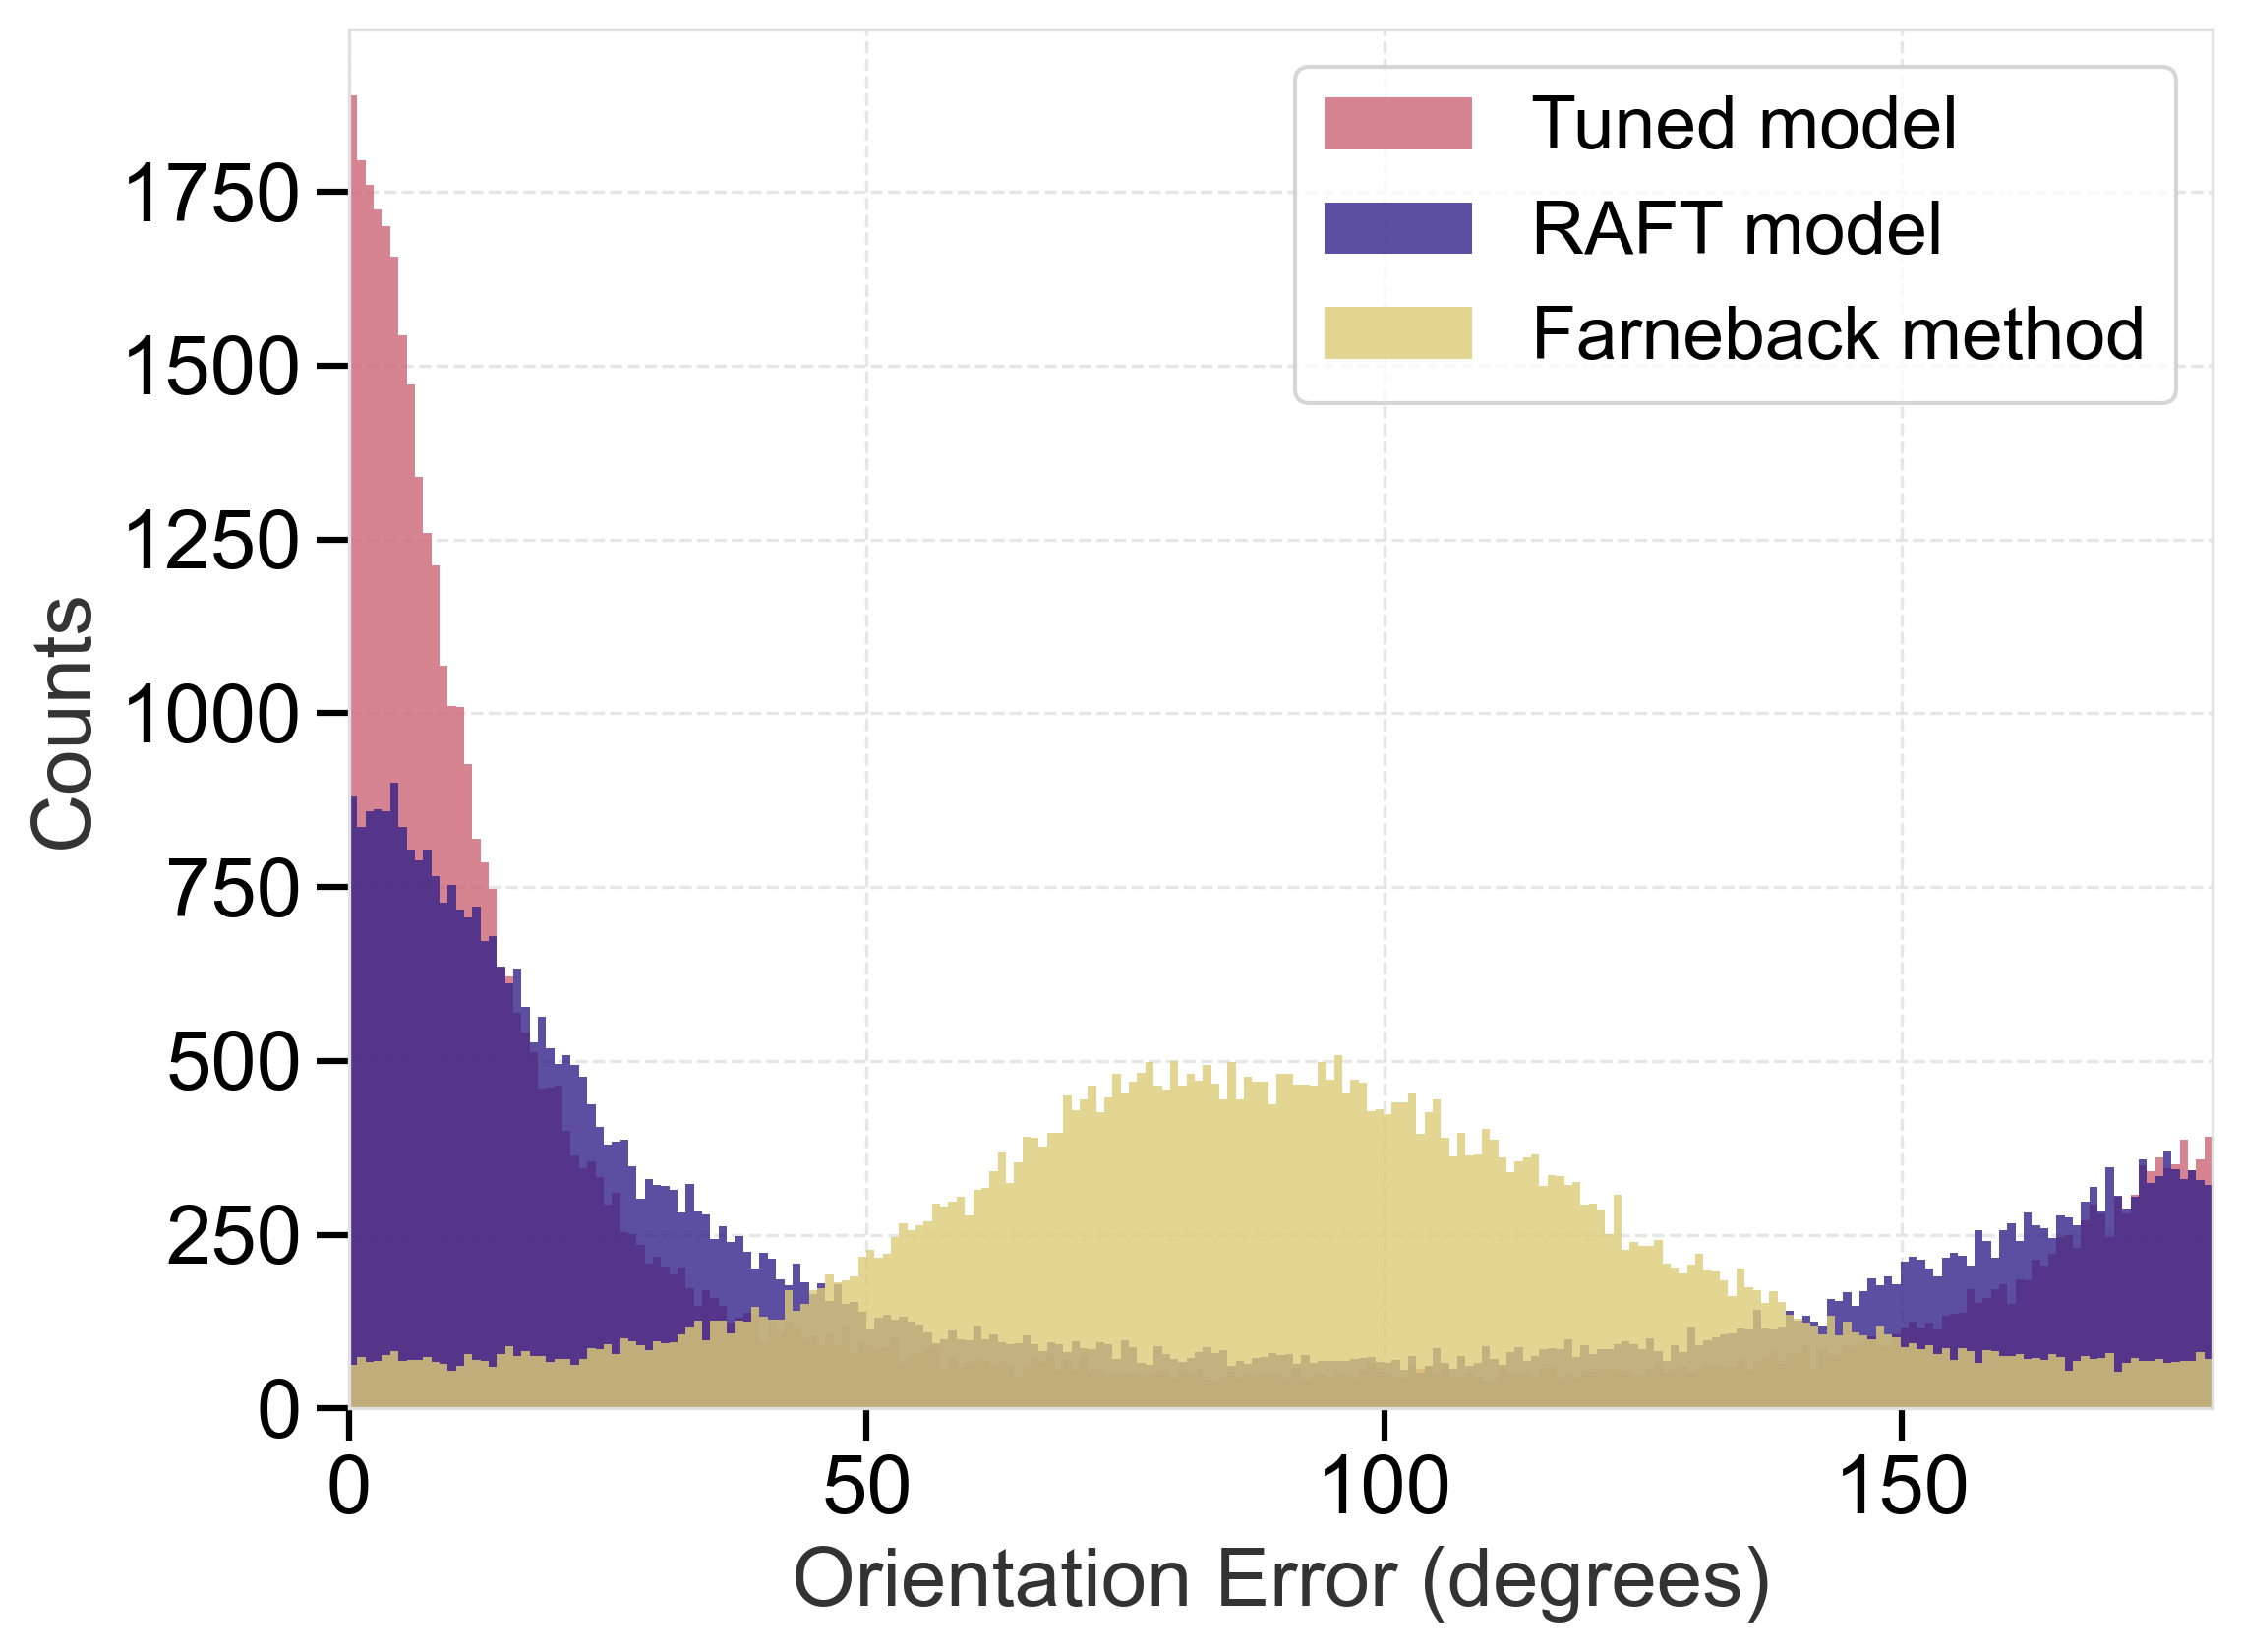

In [6]:
fig, ax = plt.subplots()
edge = np.histogram_bin_edges(good_ae, bins="sqrt")
ax.hist(good_ae, bins=edge, density=False, alpha = 0.8, label = 'Tuned model')
ax.hist(bad_ae, bins=edge, density=False, alpha = 0.8, label = 'RAFT model')
ax.hist(fb_ae, bins=edge, density=False, alpha = 0.8, label = 'Farneback method')
ax.set_xlim(0, 180)
ax.set_xlabel("Orientation Error (degrees)")
ax.set_ylabel("Counts")
ax.legend()
plt.show()

fig.savefig(save_path / 'OE.png')
fig.savefig(save_path / 'OE.pdf')